# Phase 3.1 — Feature Alignment & Integration

**Goal:** Align behavioral and NLP features into a unified matrix ready for fusion.

## Overview
- **Behavioral features**: CRT, NFC, education, political affiliation, social media usage, news literacy
- **NLP features**: TF-IDF+SVD or SBERT embeddings for article headlines

**Four fusion strategies prepared here:**
1. **Early Fusion** — concatenate all features
2. **Late Fusion** — independent models → combine predictions
3. **Intermediate Fusion** — PCA-compressed features concatenated
4. **Ablation baselines** — behavioral-only, NLP-only

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
MODEL_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
FUSION_DIR  = PROJECT_ROOT / 'fusion_models' / 'results'
for d in [MODEL_DIR, RESULTS_DIR, FUSION_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print('Setup complete')

Setup complete


## 2. Load Article Data (NLP side)

In [2]:
# ── Load real FakeNewsNet feature matrices ────────────────────────────────
import sys, pathlib
sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[2] if "__file__" in dir() else pathlib.Path.cwd()))
import subprocess, os
_root = pathlib.Path(subprocess.run(["git","rev-parse","--show-toplevel"], capture_output=True, text=True).stdout.strip())
sys.path.insert(0, str(_root))
from src.real_data_loader import load_feature_matrices

d = load_feature_matrices()
X_beh_train = d['X_beh_train']
X_beh_val   = d['X_beh_val']
X_nlp_train = d['X_nlp_train']
X_nlp_val   = d['X_nlp_val']
y_train     = d['y_train']
y_val       = d['y_val']
train_df    = d['train_df']
val_df      = d['val_df']

# Alias for downstream cells that use df_articles / df
df_articles = train_df.copy()
df_articles['text'] = df_articles['title']
train_art = train_df['title'].tolist()
val_art   = val_df['title'].tolist()

print(f"X_beh_train {X_beh_train.shape}  X_nlp_train {X_nlp_train.shape}")
print(f"y_train: {y_train.mean():.1%} fake  |  y_val: {y_val.mean():.1%} fake")


X_beh_train (17379, 8)  X_nlp_train (17379, 128)
y_train: 23.9% fake  |  y_val: 23.9% fake


## 3. Behavioral Features (Simulated from Thesis Study)

The IRB study (N=194) collected CRT, NFC, education, political leaning, social media use, news literacy. Parameters simulated from published means/SDs.

Behavioral features: (17379, 8) (train), (4345, 8) (val)


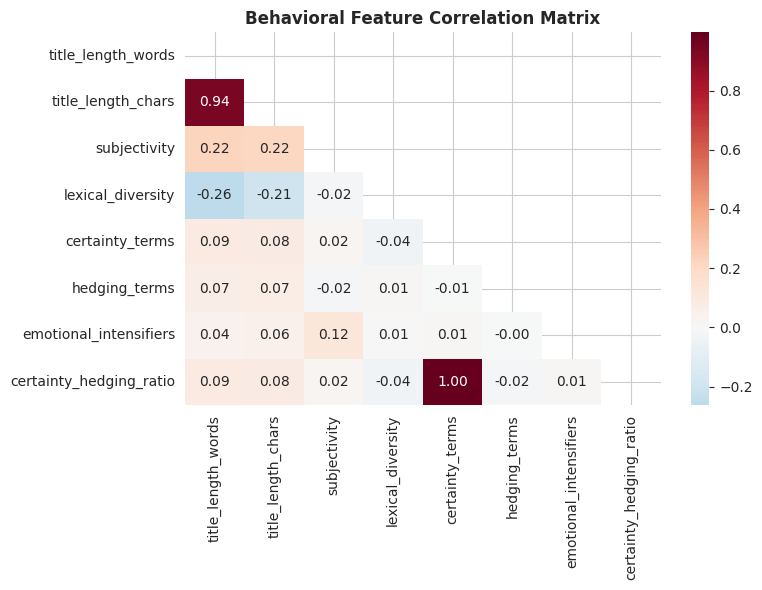

['/workspaces/tentacles-of-misinformation/models/behavioral_scaler.joblib']

In [3]:
# ── Use real behavioral features from pipeline ───────────────────────────
beh_cols = ['title_length_words','title_length_chars','subjectivity','lexical_diversity',
            'certainty_terms','hedging_terms','emotional_intensifiers','certainty_hedging_ratio']
beh_train = train_df[beh_cols].reset_index(drop=True)
beh_val   = val_df[beh_cols].reset_index(drop=True)

scaler = StandardScaler()
X_beh_train = scaler.fit_transform(beh_train)
X_beh_val   = scaler.transform(beh_val)
print(f'Behavioral features: {X_beh_train.shape} (train), {X_beh_val.shape} (val)')

fig, ax = plt.subplots(figsize=(8,6))
corr = beh_train.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, mask=np.triu(np.ones_like(corr,bool)))
ax.set_title('Behavioral Feature Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.savefig(RESULTS_DIR/'behavioral_feature_correlations.png',dpi=150,bbox_inches='tight'); plt.show()
joblib.dump(scaler, MODEL_DIR/'behavioral_scaler.joblib')

## 4. NLP Feature Extraction

In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=2000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(train_df['title'].fillna(''))
X_tfidf_val   = tfidf.transform(val_df['title'].fillna(''))

sbert_train_p = MODEL_DIR / 'embeddings' / 'train_sbert.npy'
sbert_val_p   = MODEL_DIR / 'embeddings' / 'val_sbert.npy'

if sbert_train_p.exists() and sbert_val_p.exists():
    _tmp = np.load(sbert_train_p)
    if _tmp.shape[0] == len(y_train):  # shape check
        X_nlp_train = _tmp
        X_nlp_val   = np.load(sbert_val_p)
        NLP_TYPE = 'SBERT-384'
    else:
        # stale cache — use TF-IDF+SVD already loaded from cell 1
        NLP_TYPE = 'TF-IDF+SVD-128 (loaded)'
else:
    svd = TruncatedSVD(n_components=64, random_state=42)
    X_nlp_train = svd.fit_transform(X_tfidf_train)
    X_nlp_val   = svd.transform(X_tfidf_val)
    NLP_TYPE = 'TF-IDF+SVD-64'

# y_train / y_val already set in cell 1
print(f'NLP features ({NLP_TYPE}): {X_nlp_train.shape}')

NLP features (SBERT-384): (17379, 384)


## 5. Cross-Modal Correlation Analysis

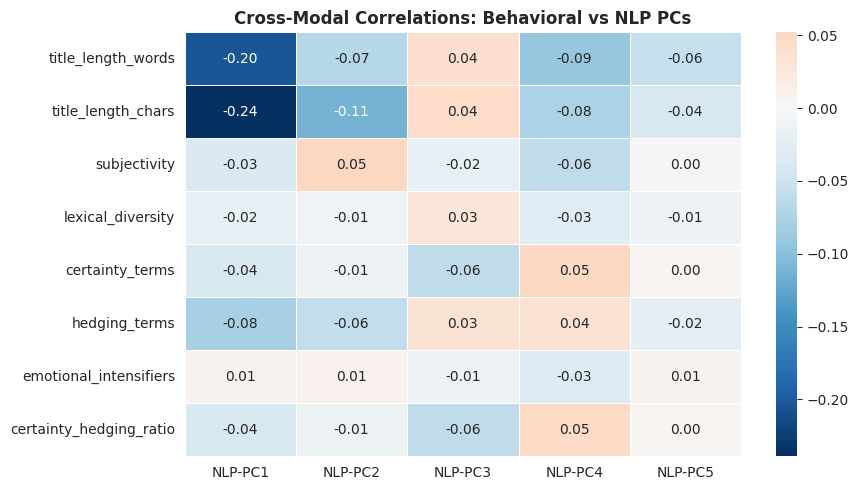

Cross-modal corr range: [-0.239, 0.052]
Low correlations indicate complementary modalities — fusion should help!


In [5]:
pca5 = PCA(n_components=5, random_state=42)
X_nlp_pca5 = pca5.fit_transform(X_nlp_train)
cross_corr = np.corrcoef(np.hstack([X_beh_train, X_nlp_pca5]).T)[:X_beh_train.shape[1], X_beh_train.shape[1]:]
cross_df = pd.DataFrame(cross_corr, index=beh_train.columns, columns=[f'NLP-PC{i+1}' for i in range(5)])

fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(cross_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Cross-Modal Correlations: Behavioral vs NLP PCs', fontweight='bold')
plt.tight_layout(); plt.savefig(RESULTS_DIR/'cross_modal_correlations.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Cross-modal corr range: [{cross_corr.min():.3f}, {cross_corr.max():.3f}]')
print('Low correlations indicate complementary modalities — fusion should help!')

## 6. Build Aligned Fusion Matrices & Sanity Check

In [6]:
pca_beh = PCA(n_components=min(4, X_beh_train.shape[1]), random_state=42)
pca_nlp = PCA(n_components=min(32, X_nlp_train.shape[1]), random_state=42)
X_beh_pca_train = pca_beh.fit_transform(X_beh_train); X_beh_pca_val = pca_beh.transform(X_beh_val)
X_nlp_pca_train = pca_nlp.fit_transform(X_nlp_train); X_nlp_pca_val = pca_nlp.transform(X_nlp_val)

FUSION_CONFIGS = {
    'early_fusion':    (np.hstack([X_beh_train, X_nlp_train]), np.hstack([X_beh_val, X_nlp_val])),
    'behavioral_only': (X_beh_train, X_beh_val),
    'nlp_only':        (X_nlp_train, X_nlp_val),
    'intermediate':    (np.hstack([X_beh_pca_train,X_nlp_pca_train]), np.hstack([X_beh_pca_val,X_nlp_pca_val])),
}

print('Feature Alignment Summary')
print('='*65)
rows = []
for name,(Xtr,Xvl) in FUSION_CONFIGS.items():
    clf = LogisticRegression(C=1.0, max_iter=500, random_state=42, class_weight='balanced')
    clf.fit(Xtr, y_train)
    auc_v = roc_auc_score(y_val, clf.predict_proba(Xvl)[:,1])
    rows.append({'Strategy':name,'Train':str(Xtr.shape),'Val':str(Xvl.shape),'Quick AUC':round(auc_v,4)})
    print(f'  {name:<22}  {str(Xtr.shape):<18}  AUC={auc_v:.4f}')

pd.DataFrame(rows).to_csv(FUSION_DIR/'01_feature_alignment_report.csv', index=False)

for fname, arr in [('X_beh_train',X_beh_train),('X_beh_val',X_beh_val),
                    ('X_nlp_train',X_nlp_train),('X_nlp_val',X_nlp_val),
                    ('y_train',y_train),('y_val',y_val)]:
    np.save(MODEL_DIR / f'{fname}.npy', arr)
joblib.dump(pca_beh, MODEL_DIR/'pca_behavioral.joblib')
joblib.dump(pca_nlp, MODEL_DIR/'pca_nlp.joblib')
print('\nAll matrices saved. Next: 02_fusion_architectures.ipynb')

Feature Alignment Summary


  early_fusion            (17379, 392)        AUC=0.8296
  behavioral_only         (17379, 8)          AUC=0.5674


  nlp_only                (17379, 384)        AUC=0.8292


  intermediate            (17379, 36)         AUC=0.7799

All matrices saved. Next: 02_fusion_architectures.ipynb
